<a href="https://colab.research.google.com/github/VinodKumarBN/DL-streetlight-failure-mapping/blob/main/Streetlight_Failure_Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn pillow tensorflow

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
PROJECT_DIR = "/content/drive/MyDrive/streetlight_project"

ZIP_PATH = f"{PROJECT_DIR}/streetcare-dataset-example.zip"
DATA_DIR = f"{PROJECT_DIR}/data"
IMAGE_DIR = f"{PROJECT_DIR}/images"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: /content/drive/MyDrive/streetlight_project


In [ ]:
URL = "https://zenodo.org/records/6046759/files/streetcare-dataset-example.zip?download=1"

if not os.path.exists(ZIP_PATH):
    !wget -q --show-progress "$URL" -O "$ZIP_PATH"
else:
    print("Dataset ZIP already exists ✅")

   /content/drive/M  94%[=================>  ] 914.53M  1.84MB/s    eta 26s    

In [ ]:
if not os.path.exists(f"{DATA_DIR}/streetcare-dataset-example"):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print("Main ZIP extracted ✅")
else:
    print("Main dataset already extracted ✅")

In [ ]:
if not os.path.exists(f"{DATA_DIR}/streetcare-dataset-example"):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print("Main ZIP extracted ✅")
else:
    print("Main dataset already extracted ✅")

In [ ]:
nested_zips = glob.glob(f"{ROOT}/*.zip")

print("Nested ZIPs:", len(nested_zips))

for zpath in nested_zips:
    with zipfile.ZipFile(zpath, "r") as z:
        z.extractall(IMAGE_DIR)

print("Images extracted ✅")

In [25]:
ROOT = f"{DATA_DIR}/streetcare-dataset-example"

print(os.listdir(ROOT))

['occurrences-example.csv', 'RSE-16-C.zip', 'RSE-46-C.zip', 'RSE-6-C.zip', 'RSE-A-11-C.zip', 'RSE-A-12-C.zip', 'RSE-A-14-C.zip', 'RSE-A-19-C.zip', 'RSE-A-21-C.zip', 'RSE-A-G-4-C.zip', 'RSE-A-G-5-C.zip', 'RSE-A-G-8-C.zip', 'RSE-L-1-C.zip', 'RSE-L-A-5-C.zip', 'RSS-12-C.zip', 'RSS-47-C.zip', 'RSS-A-2-C.zip', 'RSS-A-38-C.zip', 'streetlights-example.csv']


In [26]:
image_files = glob.glob(
    f"{IMAGE_DIR}/**/*.jpg",
    recursive=True
)

print("Total images:", len(image_files))
print(image_files[:5])

Total images: 0
[]


In [27]:
image_files = glob.glob(
    f"{IMAGE_DIR}/**/*.jpg",
    recursive=True
)

print("Total images:", len(image_files))
print(image_files[:5])

Total images: 0
[]


In [28]:
CSV_PATH = f"{ROOT}/streetlights-example.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (2412, 13)
Columns: ['id', 'serial', 'date', 'hostname', 'lat', 'lon', 'image_name', 'fault_detected', 'confidence', 'daynight', 'red', 'green', 'blue']


In [29]:
print(df["fault_detected"].value_counts(dropna=False))

fault_detected
0    2312
1     100
Name: count, dtype: int64


In [30]:
image_lookup = {
    os.path.basename(path): path
    for path in image_files
}

df["image_path"] = df["image_name"].map(image_lookup)

print("Records :", len(df))
print("Matched :", df["image_path"].notna().sum())
print("Missing :", df["image_path"].isna().sum())

Records : 2412
Matched : 0
Missing : 2412


Images found: 2412
Records : 2412
Matched : 2412
Missing : 0


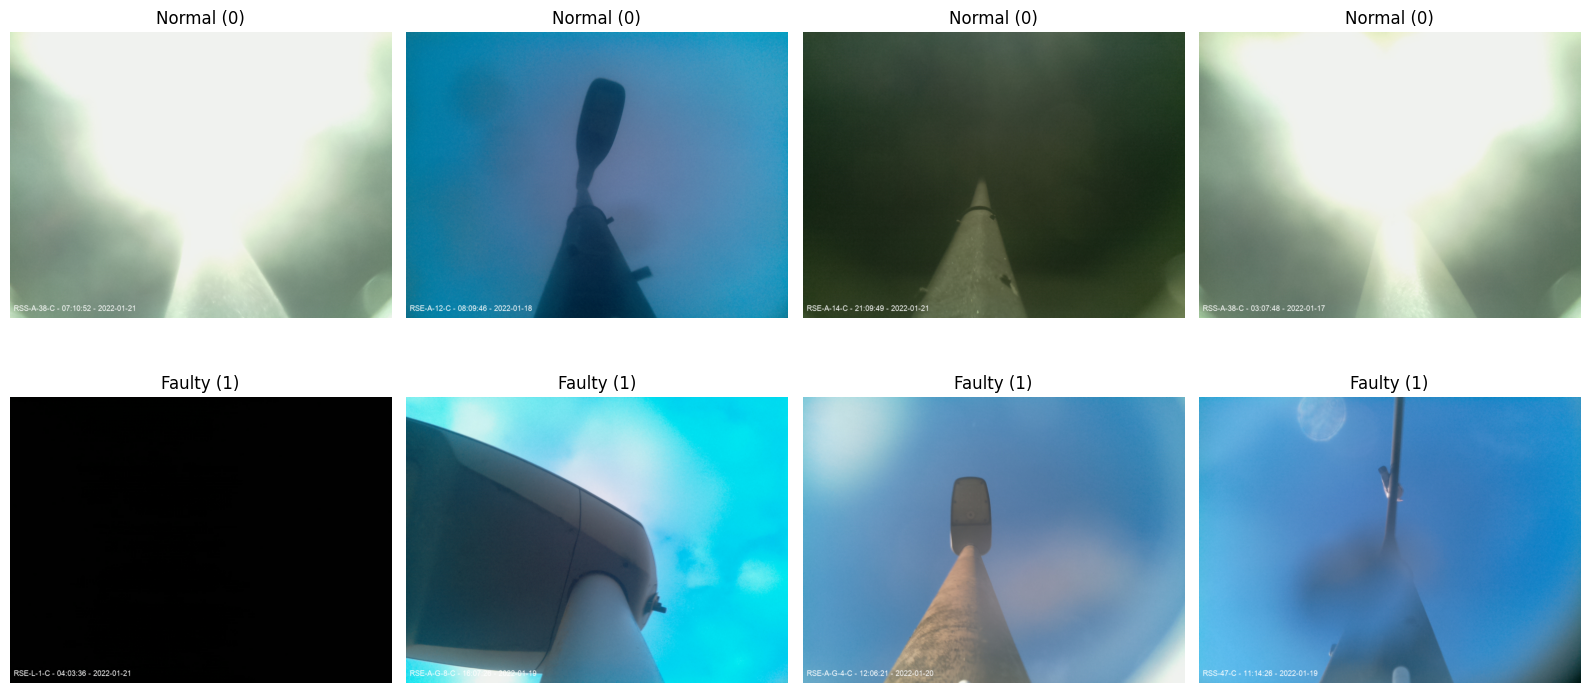

In [35]:
# ============================================================
# IMAGE EXTRACTION + IMAGE/CSV MATCHING
# ============================================================

import os
import glob
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Your existing Drive locations
PROJECT_DIR = "/content/drive/MyDrive/streetlight_project"
ZIP_PATH = f"{PROJECT_DIR}/streetcare.zip"
DATA_DIR = f"{PROJECT_DIR}/data"
IMAGE_DIR = f"{PROJECT_DIR}/images"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Extract main dataset ZIP if not already extracted
# ------------------------------------------------------------
ROOT = f"{DATA_DIR}/streetcare-dataset-example"

if not os.path.exists(ROOT):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

# ------------------------------------------------------------
# 2. Extract the 17 image ZIP files
# ------------------------------------------------------------
nested_zips = glob.glob(f"{ROOT}/*.zip")

for zpath in nested_zips:
    with zipfile.ZipFile(zpath, "r") as z:
        z.extractall(IMAGE_DIR)

# ------------------------------------------------------------
# 3. Find ALL JPG images
# ------------------------------------------------------------
image_files = glob.glob(
    f"{IMAGE_DIR}/**/*.jpg",
    recursive=True
)

print("Images found:", len(image_files))

# ------------------------------------------------------------
# 4. Create filename → full path lookup
# ------------------------------------------------------------
image_lookup = {
    os.path.basename(path): path
    for path in image_files
}

# ------------------------------------------------------------
# 5. Match CSV image_name with actual image
# ------------------------------------------------------------
df["image_path"] = df["image_name"].map(image_lookup)

print("Records :", len(df))
print("Matched :", df["image_path"].notna().sum())
print("Missing :", df["image_path"].isna().sum())

# ------------------------------------------------------------
# 6. Keep only successfully matched images
# ------------------------------------------------------------
matched_df = df.dropna(subset=["image_path"]).copy()

# ------------------------------------------------------------
# 7. Show normal + faulty examples
# ------------------------------------------------------------
normal = matched_df[
    matched_df["fault_detected"] == 0
].sample(4, random_state=42)

faulty = matched_df[
    matched_df["fault_detected"] == 1
].sample(4, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (_, row) in zip(axes[0], normal.iterrows()):
    ax.imshow(Image.open(row["image_path"]))
    ax.set_title("Normal (0)")
    ax.axis("off")

for ax, (_, row) in zip(axes[1], faulty.iterrows()):
    ax.imshow(Image.open(row["image_path"]))
    ax.set_title("Faulty (1)")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# DATA SPLIT + TENSORFLOW DATASET
# ============================================================

from sklearn.model_selection import train_test_split
import tensorflow as tf

# 1. Split: 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["fault_detected"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["fault_detected"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# 2. Image settings
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 3. Image loader
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, tf.cast(label, tf.float32)

# 4. Dataset creator
def make_dataset(dataframe, shuffle=False):

    paths = dataframe["image_path"].values
    labels = dataframe["fault_detected"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(1000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# 5. Create datasets
train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

# 6. Verify one batch
images, labels = next(iter(train_ds))

print("Images:", images.shape)
print("Labels:", labels.shape)

Train: 1688
Validation: 362
Test: 362
Images: (32, 128, 128, 3)
Labels: (32,)


In [37]:
# ============================================================
# CLASS WEIGHTS + CUSTOM CNN
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras import layers, models

# 1. Class weights
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["fault_detected"]
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print("Class weights:", class_weights)

# 2. Custom CNN
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()


Class weights: {0: np.float64(0.5216316440049443), 1: np.float64(12.057142857142857)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# ============================================================
# COMPILE + TRAIN CNN
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

# 1. Compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 2. Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# 3. Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 278ms/step - accuracy: 0.8851 - loss: 0.5032 - val_accuracy: 0.8840 - val_loss: 0.1773
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 221ms/step - accuracy: 0.8424 - loss: 0.2751 - val_accuracy: 0.8315 - val_loss: 0.2323
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 200ms/step - accuracy: 0.8578 - loss: 0.2714 - val_accuracy: 0.9696 - val_loss: 0.1541
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 23s 237ms/step - accuracy: 0.8454 - loss: 0.3311 - val_accuracy: 0.9365 - val_loss: 0.2153
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 198ms/step - accuracy: 0.8851 - loss: 0.3050 - val_accuracy: 0.8564 - val_loss: 0.2045
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 223ms/step - accuracy: 0.8744 - loss: 0.2646 - val_accuracy: 0.9061 - val_loss: 0.2584
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


              precision    recall  f1-score   support

      Normal     0.9799    0.9856    0.9828       347
      Faulty     0.6154    0.5333    0.5714        15

    accuracy                         0.9669       362
   macro avg     0.7977    0.7595    0.7771       362
weighted avg     0.9648    0.9669    0.9657       362

Confusion Matrix:
[[342   5]
 [  7   8]]


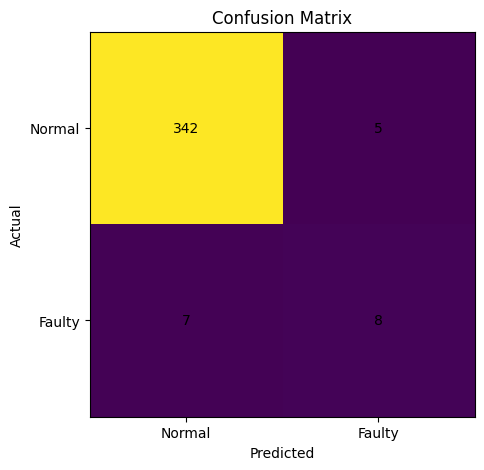

In [39]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0).ravel()

    y_true.extend(labels.numpy())
    y_prob.extend(probs)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

# Convert probability → class
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Faulty"],
    digits=4
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Normal", "Faulty"])
plt.yticks([0, 1], ["Normal", "Faulty"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.show()

In [40]:
# ============================================================
# FIND A BETTER DECISION THRESHOLD FOR FAULT DETECTION
# ============================================================

from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_prob
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-8)
)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

# Evaluate using the new threshold
y_pred_new = (y_prob >= best_threshold).astype(int)

print(
    classification_report(
        y_true,
        y_pred_new,
        target_names=["Normal", "Faulty"],
        digits=4
    )
)

Best threshold: 0.42883193
Best F1: 0.6249999950195313
              precision    recall  f1-score   support

      Normal     0.9855    0.9798    0.9827       347
      Faulty     0.5882    0.6667    0.6250        15

    accuracy                         0.9669       362
   macro avg     0.7869    0.8232    0.8038       362
weighted avg     0.9690    0.9669    0.9678       362



In [41]:
# Save trained model and optimal threshold

MODEL_PATH = "/content/drive/MyDrive/streetlight_project/streetlight_cnn.keras"

model.save(MODEL_PATH)

with open("/content/drive/MyDrive/streetlight_project/best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print("Model saved ✅")
print("Threshold saved ✅")

Model saved ✅
Threshold saved ✅


In [42]:
# ============================================================
# SINGLE IMAGE PREDICTION
# ============================================================

import numpy as np
import tensorflow as tf
from PIL import Image

def predict_streetlight(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((128, 128))

    image_array = np.array(image, dtype=np.float32) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    probability = float(model.predict(image_array, verbose=0)[0][0])

    prediction = 1 if probability >= best_threshold else 0

    status = "FAULTY" if prediction == 1 else "NORMAL"

    print(f"Prediction : {status}")
    print(f"Fault probability: {probability:.2%}")
    print(f"Threshold : {best_threshold:.4f}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"{status} | Fault probability: {probability:.2%}")
    plt.axis("off")
    plt.show()

    return prediction, probability

Prediction : NORMAL
Fault probability: 0.30%
Threshold : 0.4288


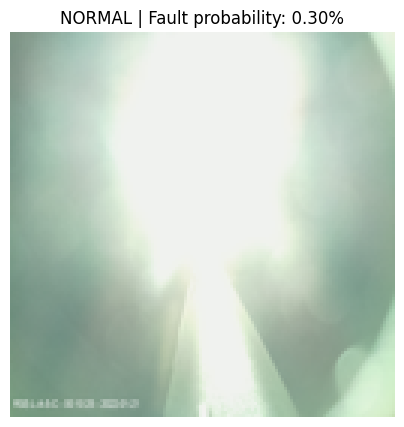

(0, 0.0030025867745280266)

In [43]:
test_image = test_df.iloc[0]["image_path"]

predict_streetlight(test_image)

In [44]:
# ============================================================
# PREDICT TEST SET + GPS DATA
# ============================================================

test_results = test_df.copy()

probabilities = []

for path in test_results["image_path"]:
    image = Image.open(path).convert("RGB").resize((128, 128))
    image_array = np.array(image, dtype=np.float32) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prob = float(model.predict(image_array, verbose=0)[0][0])
    probabilities.append(prob)

test_results["fault_probability"] = probabilities
test_results["predicted_fault"] = (
    test_results["fault_probability"] >= best_threshold
).astype(int)

print(test_results[
    ["lat", "lon", "fault_probability", "predicted_fault"]
].head())

            lat       lon  fault_probability  predicted_fault
1608  51.505191 -2.543019           0.003003                0
2260  51.505512 -2.491216           0.292708                0
1203  51.498492 -2.548403           0.000069                0
193   51.500218 -2.552446           0.149886                0
2297  51.505671 -2.526598           0.002057                0


In [45]:
# Show only predicted faulty streetlights
fault_map_df = test_results[
    test_results["predicted_fault"] == 1
].copy()

print("Predicted faulty streetlights:", len(fault_map_df))

print(
    fault_map_df[
        ["lat", "lon", "fault_probability"]
    ].head(10)
)

Predicted faulty streetlights: 17
            lat       lon  fault_probability
449   51.504171 -2.501413           0.999886
1356  51.498479 -2.548380           0.428925
166   51.505556 -2.491156           0.573934
214   51.502812 -2.550257           0.511929
1659  51.503802 -2.504214           0.999883
1460  51.506187 -2.538232           0.442036
36    51.504142 -2.501402           0.999878
105   51.500321 -2.552307           0.999878
115   51.500409 -2.552512           0.999897
1416  51.498467 -2.548421           0.432798


In [46]:
# ============================================================
# INTERACTIVE STREETLIGHT FAILURE MAP
# ============================================================

import folium

center_lat = test_results["lat"].mean()
center_lon = test_results["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=13
)

for _, row in fault_map_df.iterrows():

    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=(
            f"Fault Probability: "
            f"{row['fault_probability']:.2%}"
        ),
        icon=folium.Icon(color="red", icon="warning-sign")
    ).add_to(m)

m

In [47]:
import folium

m = folium.Map(
    location=[
        fault_map_df["lat"].mean(),
        fault_map_df["lon"].mean()
    ],
    zoom_start=13,
    tiles=None
)

folium.TileLayer(
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr="© OpenStreetMap © CARTO",
    name="CartoDB"
).add_to(m)

for _, row in fault_map_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=7,
        color="red",
        fill=True,
        fill_opacity=0.8,
        popup=f"Fault probability: {row['fault_probability']:.2%}"
    ).add_to(m)

m